<a href="https://colab.research.google.com/github/Satyabratadas/GeoEmerge_hackathon/blob/master/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

import seaborn as sns
import folium
from folium.plugins import HeatMap


end_date = "2026-01-31"

data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [4]:
land_cover = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=land_covers&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [5]:
land_cover

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
0,USA,United States,6.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89459,true,52,automatic,2026-01-31 03:33:00.000,7.3,21.3247,-158.0259,null,null,,true,null,null,null,https://data.globe.gov/system/photos/2026/01/3...,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178265728,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,408348,04QFJ010583,POINT (-158.0261 21.32383)
1,USA,United States,2.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89458,true,32,automatic,2026-01-31 03:02:00.000,4.3,21.3173,-157.8621,null,null,,false,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178386707,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409681,04QFJ180576,POINT (-157.86225 21.31648)
2,USA,United States,265.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/3...,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89457,true,25,automatic,2026-01-31 00:19:00.000,271,21.4798,-157.9967,null,null,,true,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178357780,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409676,04QFJ039755,POINT (-157.99708 21.47905)
3,USA,United States,7.9,GLOBE Data Entry Site Definition,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,None,89460,null,null,null,2026-01-31 03:49:22.993,None,None,None,M9,Urban,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,17043304,United States of America Citizen Science,land_covers,409682,Park,POINT (-158.0261 21.325)
4,USA,United States,159.2,GLOBE Observer App,null,null,pending approval,false,null,"60% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,https://data.globe.gov/system/photos/2026/01/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),[Oregon State University GEOGRAPHY],89456,true,12,automatic,2026-01-31 00:26:00.000,152.7,47.428,-122.0285,M43,"Herba

In [6]:
florida_only = land_cover[
    (land_cover["countryCode"] == "USA") & (land_cover.geometry.x.between(-87.7, -79.6)) & (land_cover.geometry.y.between(24.4, 31.1))
].copy()

In [7]:
florida_only.shape

(690, 63)

In [8]:
florida_only

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
602,USA,United States,51.2,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 231, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 312, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 314, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Standing decidusous broadleaf trees,"((compassData.heading: 169, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Cutdown trees to west.,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88833,true,5,automatic,2026-01-02 19:47:00.000,48.3,28.6467,-81.7105,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407606,17RMM305690,POINT (-81.71114 28.64624)
606,USA,United States,41.4,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 287, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 67, compassData.horizon...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 155, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 227, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Observation tower at tree canopy height. Everg...,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88836,true,5,automatic,2026-01-02 19:34:00.000,34.7,28.6474,-81.7085,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407608,17RMM307691,POINT (-81.7091 28.64716)
607,USA,United States,41.4,GLOBE Observer App,null,null,null,true,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Duplicate location with

In [9]:
fl_data = data[data["countryName"] == "United States"].copy()
fl_data = fl_data.cx[-87.7:-79.6, 24.4:31.1]  #FL bounding box
fl_data = fl_data.rename(columns={"siteId": "siteId"})

In [10]:
fl_data.shape

(625, 35)

In [11]:
merged = pd.merge(florida_only, fl_data, on="siteId")

In [12]:
merged.shape

(178, 97)

In [13]:
merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 97 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode_x                                  178 non-null    object        
 1   countryName_x                                  178 non-null    object        
 2   elevation_x                                    178 non-null    object        
 3   landcoversDataSource                           178 non-null    object        
 4   landcoversDownwardCaption                      178 non-null    object        
 5   landcoversDownwardExtraData                    178 non-null    object        
 6   landcoversDownwardPhotoUrl                     178 non-null    object        
 7   landcoversDryGround                            178 non-null    object        
 8   landcoversEastCaption                          178 n

Finish Preprocessing From GLOBE tutorial

In [29]:
data = merged 
# Let's remove the "landcovers" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("landcovers", "")
# Make the first letter of each column name capitalized (for consistency) except for geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]
data.columns = new_column_names
data['MeasuredDate'] = data['MeasuredAt'].dt.date
data['FieldNotes'] = data['FieldNotes'].replace('(none)', np.nan)
data = data.replace('null', np.nan)
countries = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/world_countries.zip')[['COUNTRY', 'geometry']].to_crs(4326)

C:\Users\dylan\AppData\Local\Temp\ipykernel_19860\3337907128.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('null', np.nan)


In [30]:
data = data.set_geometry("Geometry_x").set_geometry("Geometry_y")

In [31]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [32]:
# Let's remove the "mosquitomapper" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("Mosquitohabitatmapper", "")
data.columns = new_column_names

In [33]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 98 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode_x             178 non-null    object        
 1   CountryName_x             178 non-null    object        
 2   Elevation_x               178 non-null    object        
 3   DataSource                178 non-null    object        
 4   DownwardCaption           165 non-null    object        
 5   DownwardExtraData         165 non-null    object        
 6   DownwardPhotoUrl          178 non-null    object        
 7   DryGround                 178 non-null    object        
 8   EastCaption               164 non-null    object        
 9   EastClassifications       7 non-null      object        
 10  EastExtraData             164 non-null    object        
 11  EastPhotoUrl              178 non-null    object        
 12  Feature1Captio

EDA

In [34]:
zeros = data[data["LarvaeCount"] == 0]
zeros.shape

(0, 98)

In [35]:
type(data["LarvaeCount"])
# type(data[["LarvaeCount"]])
data

,CountryCode_x,CountryName_x,Elevation_x,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId_x,OrganizationName_x,Protocol_x,SiteId,SiteName_x,Geometry_x,CountryCode_y,CountryName_y,Elevation_y,AbdomenCloseupPhotoUrls,BreedingGroundEliminated,Comments,DataSource,ExtraData,Genus,GlobeTeams,LarvaFullBodyPhotoUrls,LarvaeCount,LastIdentifyStage,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MosquitoAdults,MosquitoEggCount,MosquitoEggs,MosquitoHabitatMapperId,MosquitoPupae,Species,Userid,WaterSource,WaterSourcePhotoUrls,WaterSourceType,OrganizationId_y,OrganizationName_y,Protocol_y,SiteName_y,Geometry_y,MeasuredDate
0,USA,United States,2.8,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2025/10/0...,false,NaN,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2025/10/0...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,House and yard on canal,None,86094,true,NaN,manual,2025-10-05 22:55:00,2,26.2152,-80.2169,M91,"Urban, Residential Property",,false,NaN,"10% MUC 02 (n) [Trees, Closely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2025/10/0...,false,false,NaN,"30% MUC 01 (b) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2025/10/0...,false,NaN,NaN,https://data.globe.gov/system/photos/2025/10/0...,171829152,NaN,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2025/10/0...,10532858,GLOBE Implementation Office GLOBE v-School,land_covers,400104,17RNJ782997,POINT (-80.21719 26.21473),USA,United States,2.8,NaN,false,Canal in City running from inland to ocean.,GLOBE Observer App,LarvaeVisibleNo,NaN,None,NaN,0,NaN,20,automatic,2025-10-08 12:15:00,0,26.2154,-80.2169,NaN,NaN,NaN,48840,false,NaN,171829152,"puddle or still water next to a creek, stream ...",NaN,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,17RNJ782997,POINT (-80.21719 26.21473),2025-10-05
1,USA,United States,6.4,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,This is in my backyard where I am doing my mos...,[SEES2023],59779,true,NaN,manual,2023-06-15 15:35:00,6,27.5877,-80.4441,NaN,NaN,,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,false,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,false,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,106918405,NaN,NaN,NaN,https://data.globe.gov/system/photos/2023/06/1...,17043304,United States of America Citizen Science,land_covers,317215,17RNL548516,POINT (-80.44476 27.58721),USA,United States,6.4,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleYes,NaN,[SEES2023],NaN,31,identify,NaN,manual,2023-06-29 20:27:00,0,27.5877,-80.4438,NaN,NaN,NaN,43291,false,NaN,106918405,"cement, metal or plastic tank",https://data.globe.gov/system/photos/2023/06/2...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,17RNL548516,POINT (-80.44476 27.58721),2023-06-15
2,USA,United States,6.4,GLOBE Ob

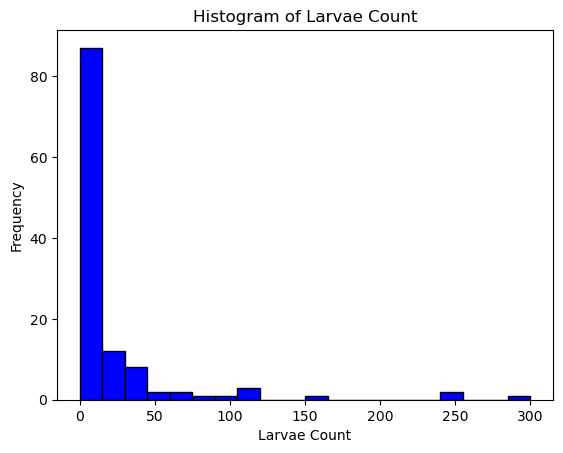

In [36]:
# Convert LarvaeCount to numeric, coercing errors to NaN
data["LarvaeCount"] = pd.to_numeric(data["LarvaeCount"], errors="coerce")
# data = data.dropna(subset=["LarvaeCount"])
# Create the histogram
plt.hist(data["LarvaeCount"], bins=20, color='blue', edgecolor='black')
plt.title("Histogram of Larvae Count")
plt.xlabel("Larvae Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
data[data["LarvaeCount"] != 0].shape

In [23]:
data.shape

(44, 98)

In [ ]:
data[data["LarvaeCount"] > 50]
# type(data[data["LarvaeCount"] > 50])
# data[data["LarvaeCount"] > 50]["Userid"].unique().tolist()

geopandas.geodataframe.GeoDataFrame

In [24]:
data[data["LarvaeCount"] > 50] 

,CountryCode_x,CountryName_x,Elevation_x,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId_x,OrganizationName_x,Protocol_x,SiteId,SiteName_x,Geometry_x,CountryCode_y,CountryName_y,Elevation_y,AbdomenCloseupPhotoUrls,BreedingGroundEliminated,Comments,DataSource,ExtraData,Genus,GlobeTeams,LarvaFullBodyPhotoUrls,LarvaeCount,LastIdentifyStage,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MosquitoAdults,MosquitoEggCount,MosquitoEggs,MosquitoHabitatMapperId,MosquitoPupae,Species,Userid,WaterSource,WaterSourcePhotoUrls,WaterSourceType,OrganizationId_y,OrganizationName_y,Protocol_y,SiteName_y,Geometry_y,MeasuredDate
13,USA,United States,1.6,GLOBE Observer App,,"(source: app, (compassData.horizon: -84.8))",https://data.globe.gov/system/photos/2022/06/2...,false,,NaN,"(source: app, (compassData.horizon: -5.2999999...",https://data.globe.gov/system/photos/2022/06/2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[SEES2022],49635,true,NaN,manual,2022-06-22 00:24:00,1.5,25.9695,-80.1299,NaN,NaN,,false,,NaN,"(source: app, (compassData.horizon: -2.1999999...",https://data.globe.gov/system/photos/2022/06/2...,false,false,,NaN,"(source: app, (compassData.horizon: 1))",https://data.globe.gov/system/photos/2022/06/2...,false,,"(source: app, (compassData.horizon: 87.2))",https://data.globe.gov/system/photos/2022/06/2...,88821137,,NaN,"(source: app, (compassData.horizon: -15))",https://data.globe.gov/system/photos/2022/06/2...,17043304,United States of America Citizen Science,land_covers,280795,17RNJ871725,POINT (-80.12993 25.96864),USA,United States,1.6,https://data.globe.gov/system/photos/2022/07/1...,true,NaN,GLOBE Observer App,LarvaeVisibleYes,NaN,[SEES2022],https://data.globe.gov/system/photos/2022/07/1...,80.0,identify-siphon-pecten,NaN,manual,2022-07-11 01:45:00,0,25.9695,-80.1295,false,NaN,false,38560,false,NaN,88821137,ovitrap,https://data.globe.gov/system/photos/2022/07/1...,container: artificial,17043304,United States of America Citizen Science,mosquito_habitat_mapper,17RNJ871725,POINT (-80.12993 25.96864),2022-06-22
14,USA,United States,1.6,GLOBE Observer App,,"(source: app, (compassData.horizon: -84.8))",https://data.globe.gov/system/photos/2022/06/2...,false,,NaN,"(source: app, (compassData.horizon: -5.2999999...",https://data.globe.gov/system/photos/2022/06/2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[SEES2022],49635,true,NaN,manual,2022-06-22 00:24:00,1.5,25.9695,-80.1299,NaN,NaN,,false,,NaN,"(source: app, (compassData.horizon: -2.1999999...",https://data.globe.gov/system/photos/2022/06/2...,false,false,,NaN,"(source: app, (compassData.horizon: 1))",https://data.globe.gov/system/photos/2022/06/2...,false,,"(source: app, (compassData.horizon: 87.2))",https://data.globe.gov/system/photos/2022/06/2...,88821137,,NaN,"(source: app, (compassData.horizon: -15))",https://data.globe.gov/system/photos/2022/06/2...,17043304,United States of America Citizen Science,land_covers,280795,17RNJ871725,POINT (-80.12993 25.96864),USA,United States,1.6,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleYes,NaN,[SEES2022],https://data.globe.gov/system/photos/2022/06/2...,250.0,identify-siphon-pecten,NaN,manual,2022-06-29 23:55:

In [ ]:
data_unique = data.drop_duplicates(subset = ['Userid'])
data_unique.shape

(15, 98)

In [56]:
data_unique['Userid'].tolist()

AttributeError: 'DataFrame' object has no attribute 'tolist'

In [ ]:
data[data["LarvaeCount"] >50].shape

(11, 98)

In [ ]:
logData = data[data["LarvaeCount"] != 0]

<function matplotlib.pyplot.show(close=None, block=None)>

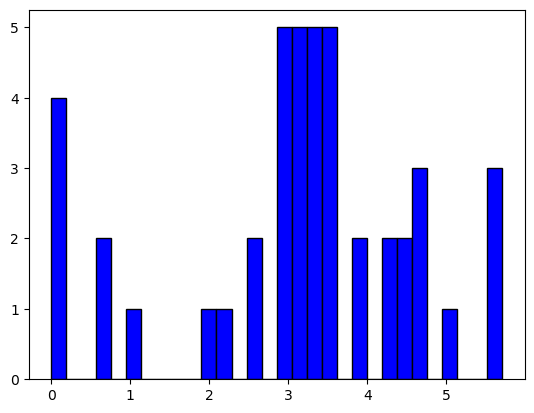

In [ ]:
plt.hist(np.log(logData["LarvaeCount"]), bins=30, color='blue', edgecolor='black')
plt.show